# OSM roads 

This notebook downloads the roads (highway) from OpenStreetMap (OSM), filters the categories of interest, sort them by priority and then applies to each noise segment the first category which is within 5 m distance. 
It adds to the dataframe also the distance between the segment and the road, and the length of the segment.
Finally, it saves all the data into a csv.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse noise dataset

In [2]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Roads - OSM

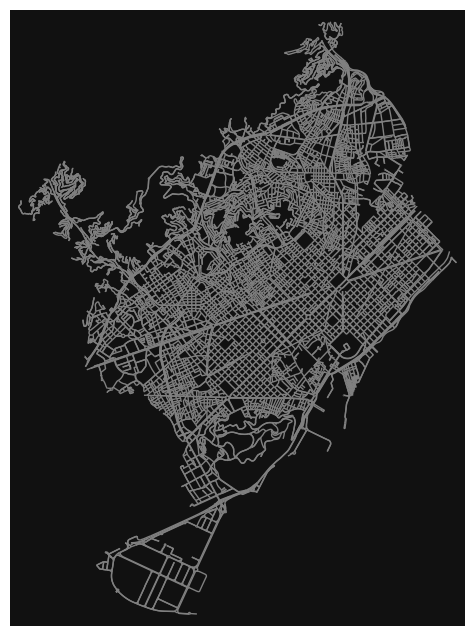

In [3]:
import osmnx as ox
#G = ox.graph_from_place("Barcelona, Spain", network_type="drive")
G = ox.load_graphml("data/barcelona.graphml")
ox.plot_graph(G, edge_color="gray", node_size=0)
ox.save_graphml(G, "barcelona.graphml")


## Prepare graph edges (roads)

In [4]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as noise_streets
roads = edges[edges.geometry.type == 'LineString'].to_crs(noise_streets.crs)
roads.to_file("bcn_osmnx_edges.gpkg", layer="edges", driver="GPKG")

## Check features completeness

In [5]:
print("Checking width..")
print(roads['width'].value_counts(dropna=False))
print("Checking maxspeed..")
print(roads['maxspeed'].value_counts(dropna=False))
print("Checking public_transport..")
print(roads['lanes'].value_counts(dropna=False))
print("Checking oneway..")
print(roads['oneway'].value_counts(dropna=False))

Checking width..
width
NaN                 14834
5                     207
6                     177
8                     154
9                     145
                    ...  
[7, 11]                 1
[6, 4.6]                1
[6, 15]                 1
9.6                     1
[3, 5, 4.8, 4.9]        1
Name: count, Length: 122, dtype: int64
Checking maxspeed..
maxspeed
30              9063
50              3892
20              1473
NaN              812
10               593
[20, 30]         316
80                98
[50, 30]          80
40                64
60                41
[10, 30]          29
[20, 10]          20
[50, 80]           8
[30, 40]           7
70                 5
[50, 40]           5
[50, 60]           4
[80, 60]           4
[50, 30, 40]       4
[20, 50]           3
[20, 10, 30]       3
[20, 50, 30]       3
4                  2
[70, 50]           2
[10, 15]           1
[50, 80, 60]       1
[20, 40]           1
[1, 30]            1
[70, 40]           1
[70, 80]      

## Check if road is tunnel

In [6]:
roads['is_tunnel'] = roads['tunnel'].fillna('no').eq('yes').astype(int)

## Filter roads categories

In [7]:
# Filter to only categories that are likely to have noise data (tunnels included)
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 16541, Filtered: 15149


## Plot road categories distribution

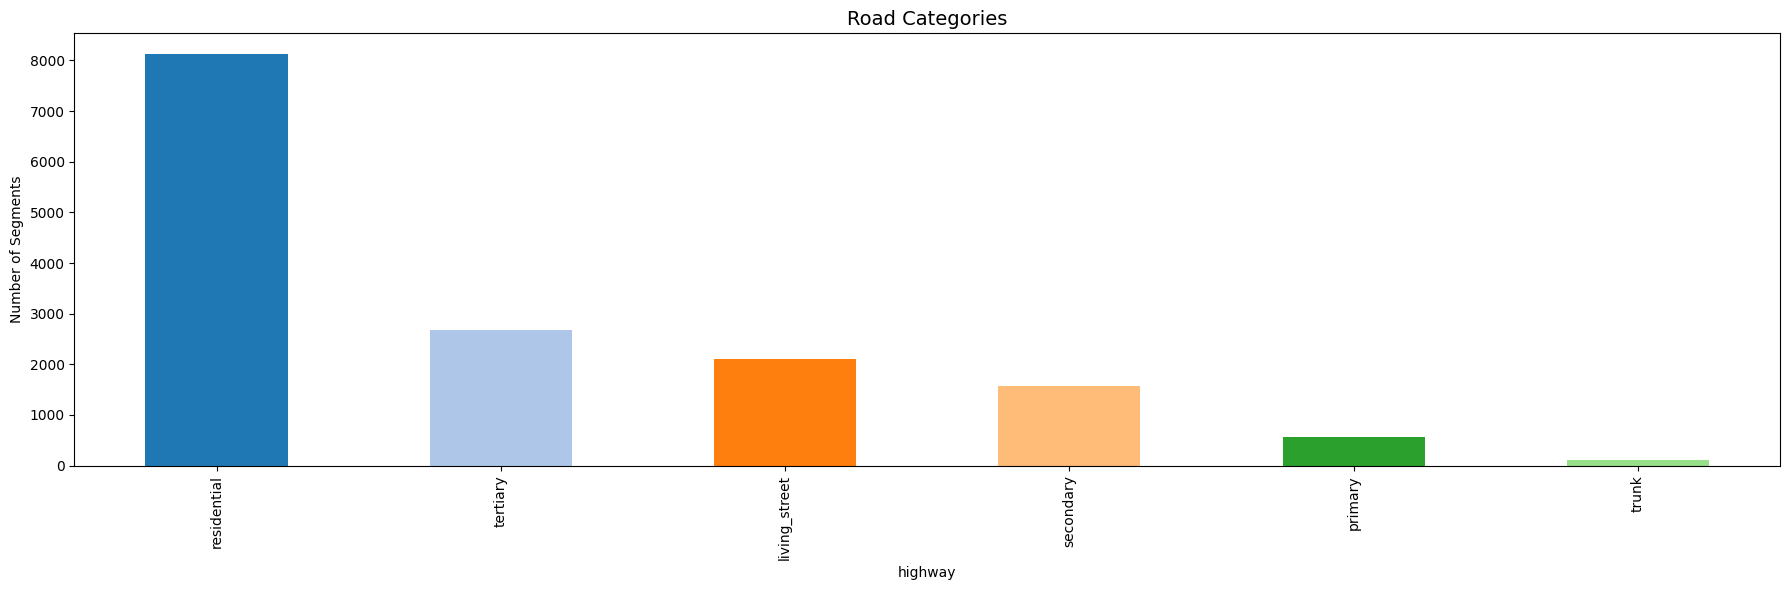

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


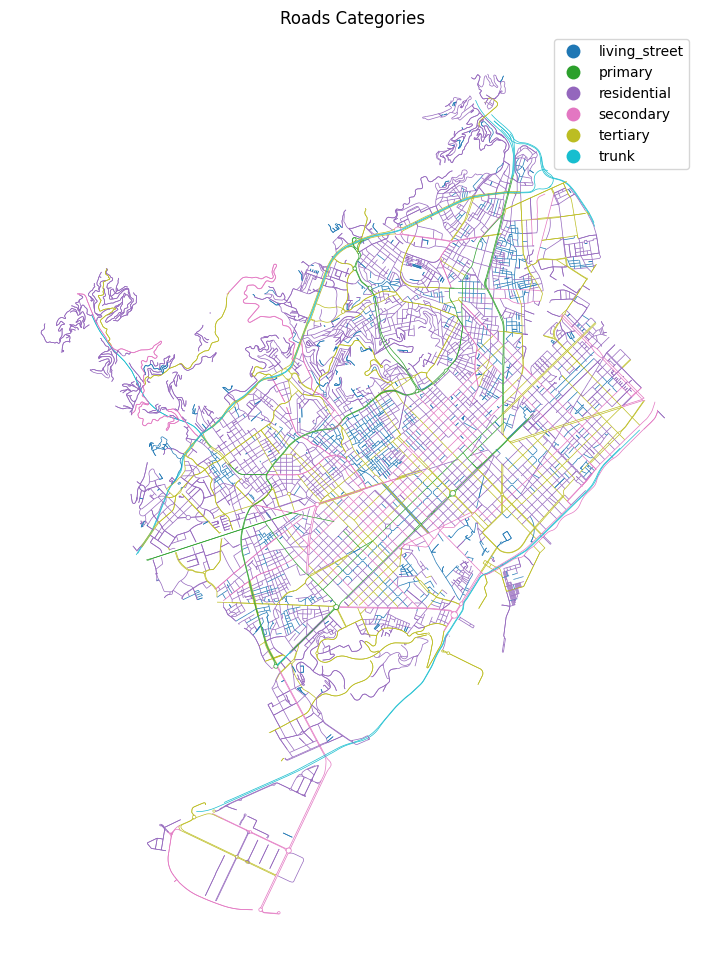

In [9]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign to each reoad segment the closest noise value

In [10]:
# Put a threshold on the distance to consider a match (e.g., 10 meters)
noise_roads = gpd.sjoin_nearest(roads_filtered, noise_streets, how='left',
                                 distance_col='distance', max_distance=10)
noise_roads = noise_roads.dropna(subset=['TOTAL_D'])  # remove unmatched roads
noise_roads = noise_roads.sort_values('distance').loc[~noise_roads.index.duplicated(keep='first')]
print(f"Before: {len(roads_filtered)}, Merged: {len(noise_roads)}")

Before: 15149, Merged: 14912


## Change noise to numerical feature

In [11]:
# Help function to convert dB string to int

def extract_min(range_str):
    if range_str == '< 40 dB(A)':
        return 35
    return int((range_str).split(' - ')[0])

print(extract_min('70 - 75 dB(A)'))

70


In [12]:
noise_roads['noise_day'] = noise_roads['TOTAL_D'].apply(extract_min)
noise_roads['noise_evening'] = noise_roads['TOTAL_E'].apply(extract_min)
noise_roads['noise_night'] = noise_roads['TOTAL_N'].apply(extract_min)

noise_roads.head()

osmid  \
u          v          key                                                      
21638891   190971702  0                               [293505299, 514849724]   
26057125   26057304   0    [542956869, 542956871, 20475367, 542956873, 25...   
3601249498 3601250399 0                                            354392077   
26057050   168319807  0                               [887560129, 185961550]   
           178518958  0                                [545747633, 22650940]   

                                 highway lanes maxspeed  \
u          v          key                                 
21638891   190971702  0         tertiary     3       30   
26057125   26057304   0        secondary     4       50   
3601249498 3601250399 0    living_street     1       20   
26057050   168319807  0          primary     7       50   
           178518958  0          primary     5       50   

                                                      name  oneway reversed  \
u          v          key                                                     
21638891   190971702  0                       Pla de Palau    True    False   
26057125   26057304   0            Ronda de la Universitat    True    False   
3601249498 3601250399 0               Passatge de Sant Pau   False    False   
26057050   168319807  0                    Plaça d'Espanya    True    False   
           178518958  0    Gran Via de les Corts Catalanes    True    False   

                               length  \
u          v          key               
21638891   190971702  0     19.151231   
26057125   26057304   0    209.249265   
3601249498 3601250399 0     52.111285   
26057050   168319807  0     57.486448   
           178518958  0    116.046758   

                                                                    geometry  \
u          v          key                                                      
21638891   190971702  0    LINESTRING (431704.221 4581554.304, 431711.35 ...   
26057125   26057304   0    LINESTRING (430484.285 4582096.5, 430453.933 4...   
3601249498 3601250399 0    LINESTRING (431078.203 4584745.289, 431048.044...   
26057050   168319807  0    LINESTRING (428799.662 4580723.152, 428800.547...   
           178518958  0    LINESTRING (428799.662 4580723.152, 428799.447...   

                          access  ...          OCI_N     PATIS_D     PATIS_E  \
u          v          key         ...                                          
21638891   190971702  0      NaN  ...  40 - 45 dB(A)  < 40 dB(A)  < 40 dB(A)   
26057125   26057304   0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
3601249498 3601250399 0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
26057050   168319807  0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   
           178518958  0      NaN  ...     < 40 dB(A)  < 40 dB(A)  < 40 dB(A)   

                          geometry_type     start       end distance  \
u          v          key                                              
21638891   190971702  0            Line  431709.0  431749.0      0.0   
26057125   26057304   0            Line  430293.0  430483.0      0.0   
3601249498 3601250399 0            Line  431043.0  431088.0      0.0   
26057050   168319807  0            Line  428812.0  428791.0      0.0   
           178518958  0            Line  428812.0  428791.0      0.0   

                          noise_day  noise_evening  noise_night  
u          v          key                                        
21638891   190971702  0          65             65           60  
26057125   26057304   0          70             65           60  
3601249498 3601250399 0          65             65           60  
26057050   168319807  0          70             65           60  
           178518958  0          70             65           60  

[5 rows x 53 columns]

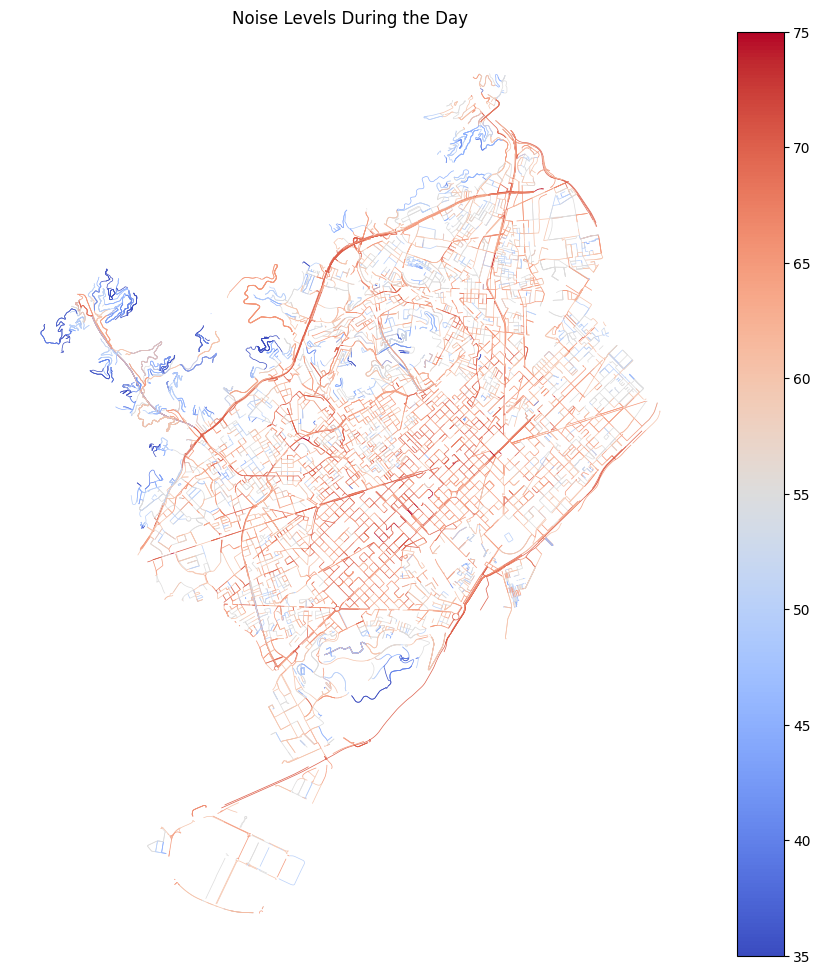

In [13]:
noise_roads['noise_day'] = noise_roads['noise_day']
ax = noise_roads.plot(cmap="coolwarm", column='noise_day', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Noise Levels During the Day')
ax.set_axis_off()

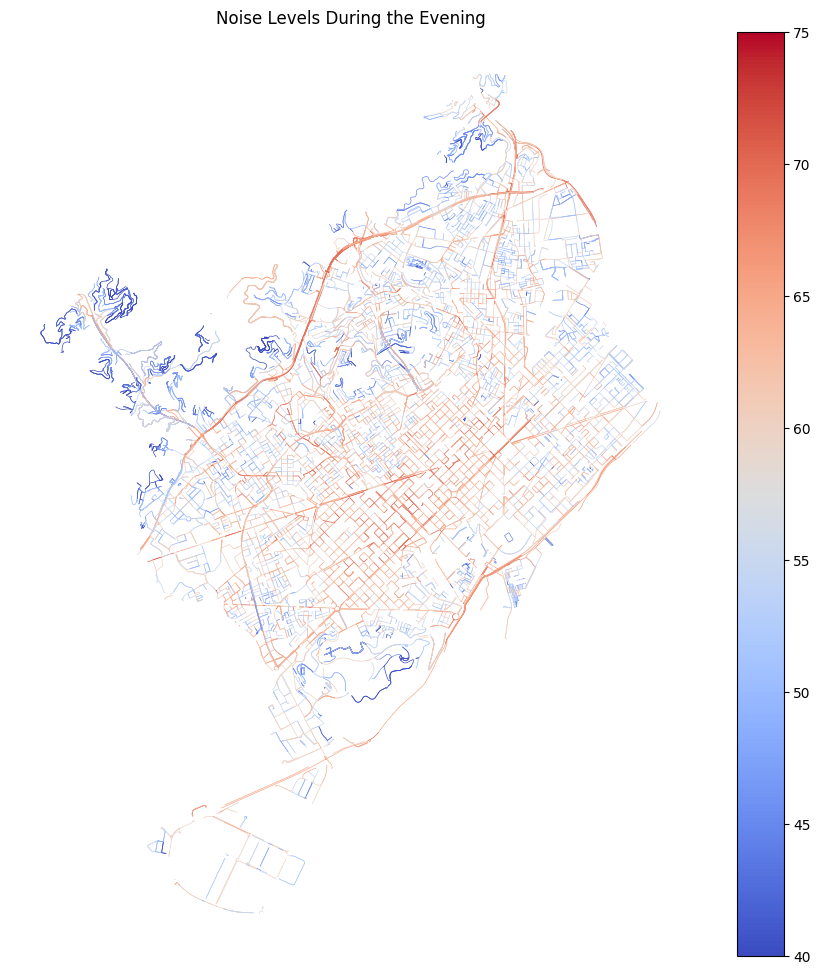

In [14]:
noise_roads['noise_evening'] = noise_roads['noise_evening']
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', linewidth=0.5, legend=True, figsize=(12, 12), vmin=40, vmax=75)
ax.set_title('Noise Levels During the Evening')
ax.set_axis_off()

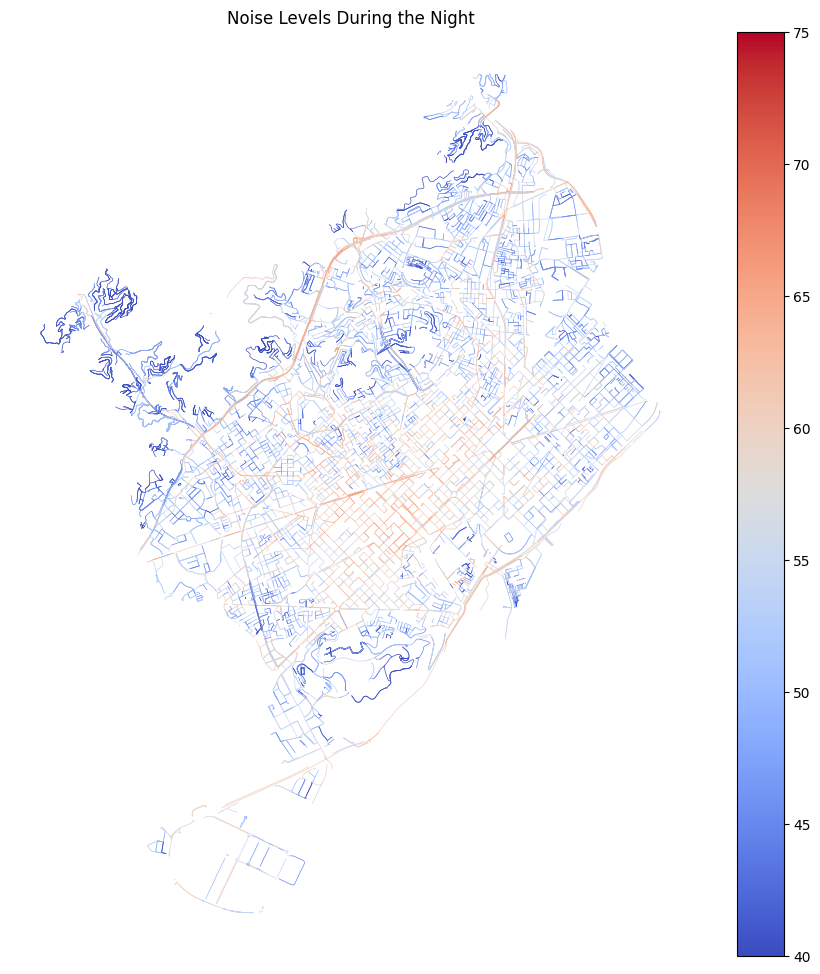

In [15]:
noise_roads['noise_night'] = noise_roads['noise_night']
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', linewidth=0.5, legend=True, figsize=(12, 12),  vmin=40, vmax=75)
ax.set_title('Noise Levels During the Night')
ax.set_axis_off()

## Convert category to numerical feature

In [16]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      8105
tertiary         2452
living_street    2119
secondary        1399
primary           613
trunk             224
Name: count, dtype: int64

In [17]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

osmid  \
u          v          key                                                      
21638891   190971702  0                               [293505299, 514849724]   
26057125   26057304   0    [542956869, 542956871, 20475367, 542956873, 25...   
3601249498 3601250399 0                                            354392077   
26057050   168319807  0                               [887560129, 185961550]   
           178518958  0                                [545747633, 22650940]   

                                 highway lanes maxspeed  \
u          v          key                                 
21638891   190971702  0         tertiary     3       30   
26057125   26057304   0        secondary     4       50   
3601249498 3601250399 0    living_street     1       20   
26057050   168319807  0          primary     7       50   
           178518958  0          primary     5       50   

                                                      name  oneway reversed  \
u          v          key                                                     
21638891   190971702  0                       Pla de Palau    True    False   
26057125   26057304   0            Ronda de la Universitat    True    False   
3601249498 3601250399 0               Passatge de Sant Pau   False    False   
26057050   168319807  0                    Plaça d'Espanya    True    False   
           178518958  0    Gran Via de les Corts Catalanes    True    False   

                               length  \
u          v          key               
21638891   190971702  0     19.151231   
26057125   26057304   0    209.249265   
3601249498 3601250399 0     52.111285   
26057050   168319807  0     57.486448   
           178518958  0    116.046758   

                                                                    geometry  \
u          v          key                                                      
21638891   190971702  0    LINESTRING (431704.221 4581554.304, 431711.35 ...   
26057125   26057304   0    LINESTRING (430484.285 4582096.5, 430453.933 4...   
3601249498 3601250399 0    LINESTRING (431078.203 4584745.289, 431048.044...   
26057050   168319807  0    LINESTRING (428799.662 4580723.152, 428800.547...   
           178518958  0    LINESTRING (428799.662 4580723.152, 428799.447...   

                          access  ...     PATIS_E geometry_type     start  \
u          v          key         ...                                       
21638891   190971702  0      NaN  ...  < 40 dB(A)          Line  431709.0   
26057125   26057304   0      NaN  ...  < 40 dB(A)          Line  430293.0   
3601249498 3601250399 0      NaN  ...  < 40 dB(A)          Line  431043.0   
26057050   168319807  0      NaN  ...  < 40 dB(A)          Line  428812.0   
           178518958  0      NaN  ...  < 40 dB(A)          Line  428812.0   

                                end distance noise_day noise_evening  \
u          v          key                                              
21638891   190971702  0    431749.0      0.0        65            65   
26057125   26057304   0    430483.0      0.0        70            65   
3601249498 3601250399 0    431088.0      0.0        65            65   
26057050   168319807  0    428791.0      0.0        70            65   
           178518958  0    428791.0      0.0        70            65   

                          noise_night  road_category  category_code  
u          v          key                                            
21638891   190971702  0            60       tertiary              4  
26057125   26057304   0            60      secondary              3  
3601249498 3601250399 0            60  living_street              6  
26057050   168319807  0            60        primary              2  
           178518958  0            60        primary              2  

[5 rows x 55 columns]

## Calculate distance to the closest road of each category

In [18]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = roads_filtered[roads_filtered['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()


,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,"[293505299, 514849724]",tertiary,3,30,Pla de Palau,True,False,19.151231,"LINESTRING (431704.221 4581554.304, 431711.35 ...",NaN,...,65,60,tertiary,4,143.325492,1409.121451,146.914702,0.000000,151.351124,184.454492
1,"[542956869, 542956871, 20475367, 542956873, 25...",secondary,4,50,Ronda de la Universitat,True,False,209.249265,"LINESTRING (430484.285 4582096.5, 430453.933 4...",NaN,...,65,60,secondary,3,1364.261619,108.740116,0.000000,138.887494,0.000000,137.141496
2,354392077,living_street,1,20,Passatge de Sant Pau,False,False,52.111285,"LINESTRING (431078.203 4584745.289, 431048.044...",NaN,...,65,60,living_street,6,3061.643369,399.680682,0.000000,406.820267,62.359815,0.000000
3,"[887560129, 185961550]",primary,7,50,Plaça d'Espanya,True,False,57.486448,"LINESTRING (428799.662 4580723.152, 428800.547...",NaN,...,65,60,primary,2,1146.109648,0.000000,40.129104,0.000000,102.118862,130.263370
4,"[545747633, 22650940]",primary,5,50,Gran Via de les Corts Catalanes,True,False,116.046758,"LINESTRING (428799.662 4580723.152, 428799.447...",NaN,...,65,60,primary,2,1039.406813,0.000000,81.607990,10.012431,0.000000,130.263370


In [19]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,11425.000000,11425.000000,11425.000000,11425.000000,11425.000000,11425.000000
mean,1114.258128,723.403812,357.127499,134.357939,12.273681,142.914498
std,808.080606,773.553226,396.730376,157.162660,38.340864,266.138116
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,399.024205,183.392466,59.742268,0.000000,0.000000,0.000000
50%,997.715960,496.726079,242.977100,94.792701,0.000000,70.504980
75%,1741.247403,1009.092242,515.980618,206.685696,0.000000,166.392437
max,3095.683597,4669.844695,2567.140076,1060.917082,725.111180,2415.828166


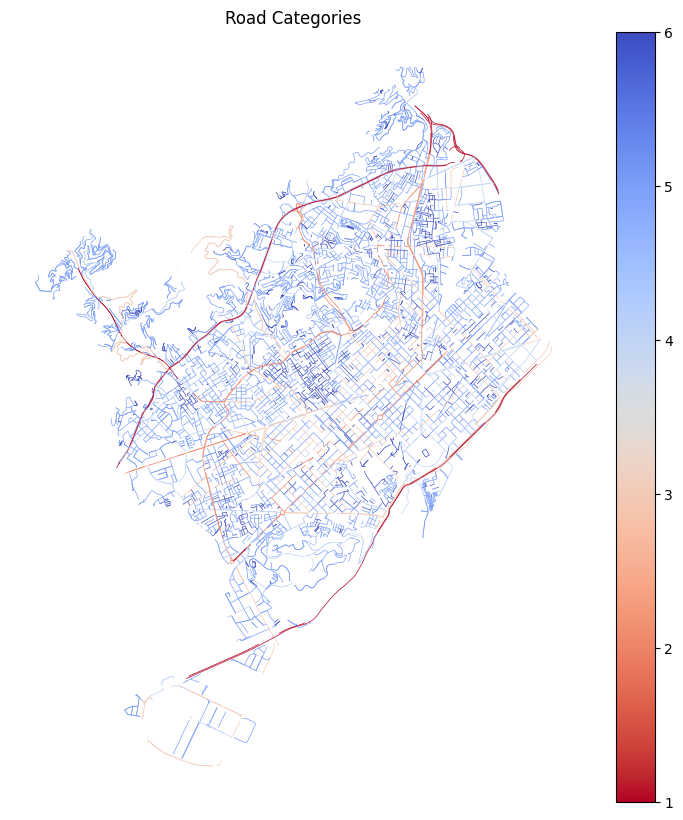

In [20]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='coolwarm_r', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [21]:
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,"[293505299, 514849724]",tertiary,3,30,Pla de Palau,True,False,19.151231,"LINESTRING (431704.221 4581554.304, 431711.35 ...",NaN,...,65,60,tertiary,4,143.325492,1409.121451,146.914702,0.000000,151.351124,184.454492
1,"[542956869, 542956871, 20475367, 542956873, 25...",secondary,4,50,Ronda de la Universitat,True,False,209.249265,"LINESTRING (430484.285 4582096.5, 430453.933 4...",NaN,...,65,60,secondary,3,1364.261619,108.740116,0.000000,138.887494,0.000000,137.141496
2,354392077,living_street,1,20,Passatge de Sant Pau,False,False,52.111285,"LINESTRING (431078.203 4584745.289, 431048.044...",NaN,...,65,60,living_street,6,3061.643369,399.680682,0.000000,406.820267,62.359815,0.000000
3,"[887560129, 185961550]",primary,7,50,Plaça d'Espanya,True,False,57.486448,"LINESTRING (428799.662 4580723.152, 428800.547...",NaN,...,65,60,primary,2,1146.109648,0.000000,40.129104,0.000000,102.118862,130.263370
4,"[545747633, 22650940]",primary,5,50,Gran Via de les Corts Catalanes,True,False,116.046758,"LINESTRING (428799.662 4580723.152, 428799.447...",NaN,...,65,60,primary,2,1039.406813,0.000000,81.607990,10.012431,0.000000,130.263370


## Create data frame

In [22]:
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]

dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'],
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{col: noise_roads[col] for col in distance_cols},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,21638891_190971702_0,65,65,60,4,143.325492,1409.121451,146.914702,0.000000,151.351124,184.454492
1,26057125_26057304_0,70,65,60,3,1364.261619,108.740116,0.000000,138.887494,0.000000,137.141496
2,3601249498_3601250399_0,65,65,60,6,3061.643369,399.680682,0.000000,406.820267,62.359815,0.000000
3,26057050_168319807_0,70,65,60,2,1146.109648,0.000000,40.129104,0.000000,102.118862,130.263370
4,26057050_178518958_0,70,65,60,2,1039.406813,0.000000,81.607990,10.012431,0.000000,130.263370


## Export dataset to CSV

In [23]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_regre_with_tunnels.csv"), index=False)
print("Exported osm_roads_noise_regre_with_tunnels.csv")

Exported osm_roads_noise_regre_with_tunnels.csv
